In [ ]:
# ==========================================================
# German Electricity Demand Forecasting
# Part 1 - Data Download and Initial Inspection
# ==========================================================

# Install required packages (safe to run in Colab)
!pip -q install holidays pmdarima

# Import libraries
import warnings
warnings.filterwarnings("ignore")

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Display settings
pd.set_option("display.max_columns", None)
plt.style.use("ggplot")
plt.rcParams["figure.figsize"] = (14,6)

print("="*60)
print("German Electricity Demand Forecasting")
print("="*60)

# ------------------------------------------------------------------
# Download the Open Power System Data (OPSD) dataset
# ------------------------------------------------------------------

url = "https://data.open-power-system-data.org/time_series/2020-10-06/time_series_60min_singleindex.csv"

print("\nDownloading dataset...")
df = pd.read_csv(url, parse_dates=["utc_timestamp"])

print("Download completed.")

# ------------------------------------------------------------------
# Basic inspection
# ------------------------------------------------------------------

print("\nDataset Shape:")
print(df.shape)

print("\nFirst 5 rows:")
display(df.head())

print("\nColumn names:")
display(df.columns.tolist())

# ------------------------------------------------------------------
# Find Germany electricity load columns
# ------------------------------------------------------------------

germany_columns = [col for col in df.columns if "DE" in col and "load" in col.lower()]

print("\nGerman Load Columns:")
print(germany_columns)

German Electricity Demand Forecasting

Download completed.

Dataset Shape:
(50401, 300)

First 5 rows:


,utc_timestamp,cet_cest_timestamp,AT_load_actual_entsoe_transparency,AT_load_forecast_entsoe_transparency,AT_price_day_ahead,AT_solar_generation_actual,AT_wind_onshore_generation_actual,BE_load_actual_entsoe_transparency,BE_load_forecast_entsoe_transparency,BE_solar_generation_actual,BE_wind_generation_actual,BE_wind_offshore_generation_actual,BE_wind_onshore_generation_actual,BG_load_actual_entsoe_transparency,BG_load_forecast_entsoe_transparency,BG_solar_generation_actual,BG_wind_onshore_generation_actual,CH_load_actual_entsoe_transparency,CH_load_forecast_entsoe_transparency,CH_solar_capacity,CH_solar_generation_actual,CH_wind_onshore_capacity,CH_wind_onshore_generation_actual,CY_load_actual_entsoe_transparency,CY_load_forecast_entsoe_transparency,CY_wind_onshore_generation_actual,CZ_load_actual_entsoe_transparency,CZ_load_forecast_entsoe_transparency,CZ_solar_generation_actual,CZ_wind_onshore_generation_actual,DE_load_actual_entsoe_transparency,DE_load_forecast_entsoe_transparency,DE_solar_capacity,DE_solar_generation_actual,DE_solar_profile,DE_wind_capacity,DE_wind_generation_actual,DE_wind_profile,DE_wind_offshore_capacity,DE_wind_offshore_generation_actual,DE_wind_offshore_profile,DE_wind_onshore_capacity,DE_wind_onshore_generation_actual,DE_wind_onshore_profile,DE_50hertz_load_actual_entsoe_transparency,DE_50hertz_load_forecast_entsoe_transparency,DE_50hertz_solar_generation_actual,DE_50hertz_wind_generation_actual,DE_50hertz_wind_offshore_generation_actual,DE_50hertz_wind_onshore_generation_actual,DE_LU_load_actual_entsoe_transparency,DE_LU_load_forecast_entsoe_transparency,DE_LU_price_day_ahead,DE_LU_solar_generation_actual,DE_LU_wind_generation_actual,DE_LU_wind_offshore_generation_actual,DE_LU_wind_onshore_generation_actual,DE_amprion_load_actual_entsoe_transparency,DE_amprion_load_forecast_entsoe_transparency,DE_amprion_solar_generation_actual,DE_amprion_wind_onshore_generation_actual,DE_tennet_load_actual_entsoe_transparency,DE_tennet_load_forecast_entsoe_transparency,DE_tennet_solar_generation_actual,DE_tennet_wind_generation_actual,DE_tennet_wind_offshore_generation_actual,DE_tennet_wind_onshore_generation_actual,DE_transnetbw_load_actual_entsoe_transparency,DE_transnetbw_load_forecast_entsoe_transparency,DE_transnetbw_solar_generation_actual,DE_transnetbw_wind_onshore_generation_actual,DK_load_actual_entsoe_transparency,DK_load_forecast_entsoe_transparency,DK_solar_capacity,DK_solar_generation_actual,DK_wind_capacity,DK_wind_generation_actual,DK_wind_offshore_capacity,DK_wind_offshore_generation_actual,DK_wind_onshore_capacity,DK_wind_onshore_generation_actual,DK_1_load_actual_entsoe_transparency,DK_1_load_forecast_entsoe_transparency,DK_1_price_day_ahead,DK_1_solar_generation_actual,DK_1_wind_generation_actual,DK_1_wind_offshore_generation_actual,DK_1_wind_onshore_generation_actual,DK_2_load_actual_entsoe_transparency,DK_2_load_forecast_entsoe_transparency,DK_2_price_day_ahead,DK_2_solar_generation_actual,DK_2_wind_generation_actual,DK_2_wind_offshore_generation_actual,DK_2_wind_onshore_generation_actual,EE_load_actual_entsoe_transparency,EE_load_forecast_entsoe_transparency,EE_solar_generation_actual,EE_wind_onshore_generation_actual,ES_load_actual_entsoe_transparency,ES_load_forecast_entsoe_transparency,ES_solar_generation_actual,ES_wind_onshore_generation_actual,FI_load_actual_entsoe_transparency,FI_load_forecast_entsoe_transparency,FI_wind_onshore_generation_actual,FR_load_actual_entsoe_transparency,FR_load_forecast_entsoe_transparency,FR_solar_generation_actual,FR_wind_onshore_generation_actual,GB_GBN_load_actual_entsoe_transparency,GB_GBN_load_forecast_entsoe_transparency,GB_GBN_price_day_ahead,GB_GBN_solar_capacity,GB_GBN_solar_generation_actual,GB_GBN_solar_profile,GB_GBN_wind_capacity,GB_GBN_wind_generation_actual,GB_GBN_wind_profile,GB_GBN_wind_offshore_capacity,GB_GBN_wind_offshore_generation_actual,GB_GBN_wind_offshore_profile,GB_GBN_wind_onshore_capacity,GB_GBN_wind_onshore_generation_actual,GB_G


Column names:


['utc_timestamp',
 'cet_cest_timestamp',
 'AT_load_actual_entsoe_transparency',
 'AT_load_forecast_entsoe_transparency',
 'AT_price_day_ahead',
 'AT_solar_generation_actual',
 'AT_wind_onshore_generation_actual',
 'BE_load_actual_entsoe_transparency',
 'BE_load_forecast_entsoe_transparency',
 'BE_solar_generation_actual',
 'BE_wind_generation_actual',
 'BE_wind_offshore_generation_actual',
 'BE_wind_onshore_generation_actual',
 'BG_load_actual_entsoe_transparency',
 'BG_load_forecast_entsoe_transparency',
 'BG_solar_generation_actual',
 'BG_wind_onshore_generation_actual',
 'CH_load_actual_entsoe_transparency',
 'CH_load_forecast_entsoe_transparency',
 'CH_solar_capacity',
 'CH_solar_generation_actual',
 'CH_wind_onshore_capacity',
 'CH_wind_onshore_generation_actual',
 'CY_load_actual_entsoe_transparency',
 'CY_load_forecast_entsoe_transparency',
 'CY_wind_onshore_generation_actual',
 'CZ_load_actual_entsoe_transparency',
 'CZ_load_forecast_entsoe_transparency',
 'CZ_solar_generation_


German Load Columns:
['DE_load_actual_entsoe_transparency', 'DE_load_forecast_entsoe_transparency', 'DE_50hertz_load_actual_entsoe_transparency', 'DE_50hertz_load_forecast_entsoe_transparency', 'DE_LU_load_actual_entsoe_transparency', 'DE_LU_load_forecast_entsoe_transparency', 'DE_amprion_load_actual_entsoe_transparency', 'DE_amprion_load_forecast_entsoe_transparency', 'DE_tennet_load_actual_entsoe_transparency', 'DE_tennet_load_forecast_entsoe_transparency', 'DE_transnetbw_load_actual_entsoe_transparency', 'DE_transnetbw_load_forecast_entsoe_transparency']


In [ ]:
# ==========================================================
# Part 1 - Data Cleaning and Time Aggregation
# ==========================================================

# Select Germany electricity demand column
load_column = "DE_load_actual_entsoe_transparency"

data = df[["utc_timestamp", load_column]].copy()

# Rename columns for easier use
data = data.rename(columns={
    "utc_timestamp": "datetime",
    load_column: "load"
})

# Set datetime as index
data = data.set_index("datetime")

# Keep only data from 1 January 2015 to the end of the file
data = data.loc["2015-01-01":]

# Check missing values before cleaning
print("Missing values before cleaning:")
print(data.isna().sum())

# Remove missing values
data = data.dropna()

# Check missing values after cleaning
print("\nMissing values after cleaning:")
print(data.isna().sum())

# Create daily and weekly average electricity demand
daily_data = data.resample("D").mean()
weekly_data = data.resample("W").mean()

print("\nHourly data shape:", data.shape)
print("Daily data shape:", daily_data.shape)
print("Weekly data shape:", weekly_data.shape)

print("\nHourly data date range:")
print(data.index.min(), "to", data.index.max())

print("\nDaily data preview:")
display(daily_data.head())

print("\nWeekly data preview:")
display(weekly_data.head())

Missing values before cleaning:
load    0
dtype: int64

Missing values after cleaning:
load    0
dtype: int64

Hourly data shape: (50400, 1)
Daily data shape: (2100, 1)
Weekly data shape: (301, 1)

Hourly data date range:
2015-01-01 00:00:00+00:00 to 2020-09-30 23:00:00+00:00

Daily data preview:


,load
datetime,
2015-01-01 00:00:00+00:00,45346.541667
2015-01-02 00:00:00+00:00,51941.166667
2015-01-03 00:00:00+00:00,46564.750000
2015-01-04 00:00:00+00:00,45082.500000
2015-01-05 00:00:00+00:00,55246.666667



Weekly data preview:


,load
datetime,
2015-01-04 00:00:00+00:00,47233.739583
2015-01-11 00:00:00+00:00,56191.101190
2015-01-18 00:00:00+00:00,57672.678571
2015-01-25 00:00:00+00:00,58613.303571
2015-02-01 00:00:00+00:00,58734.029762


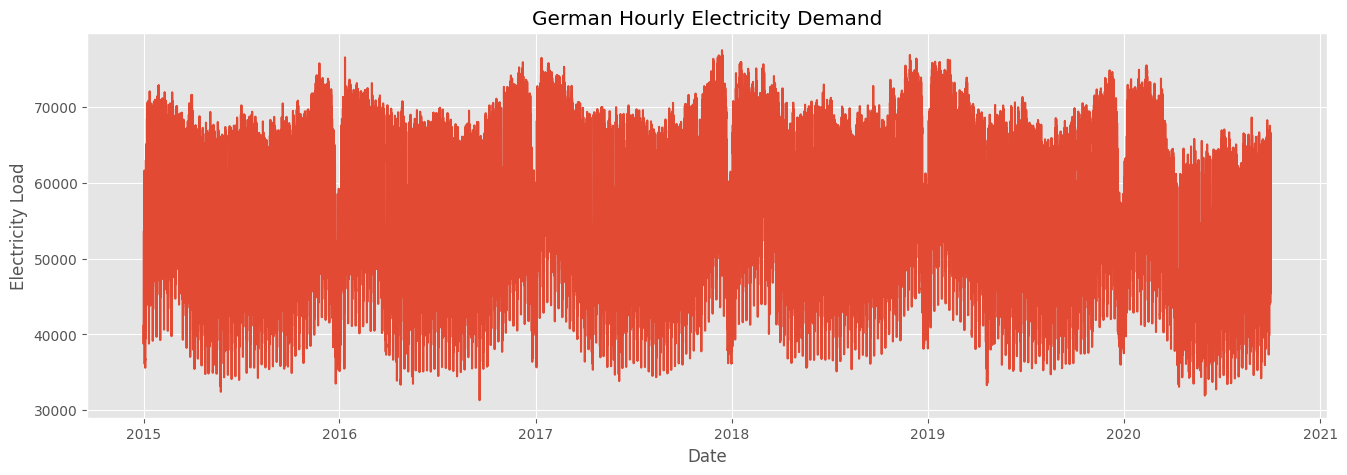

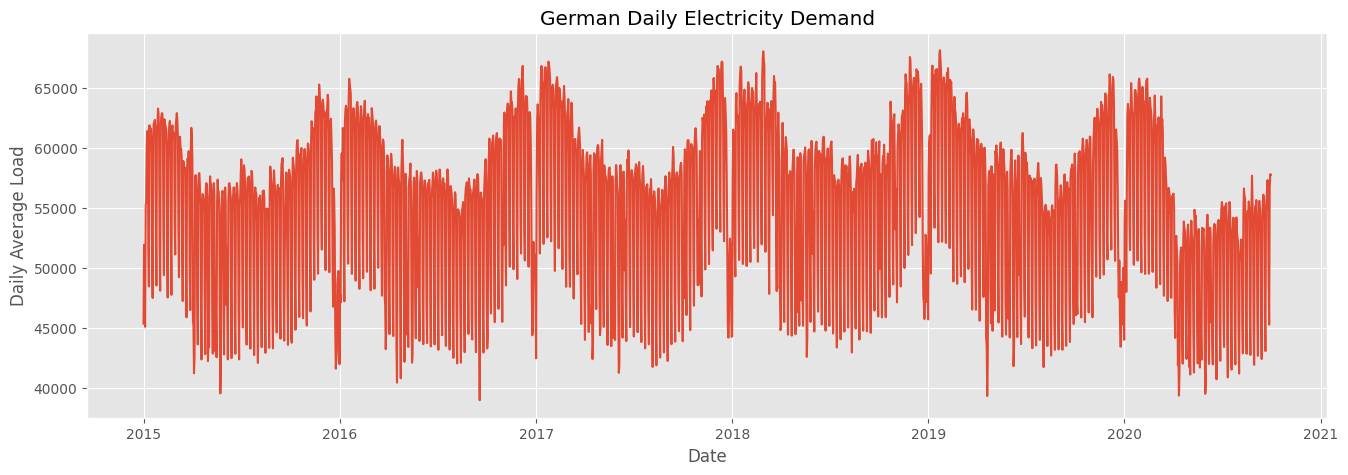

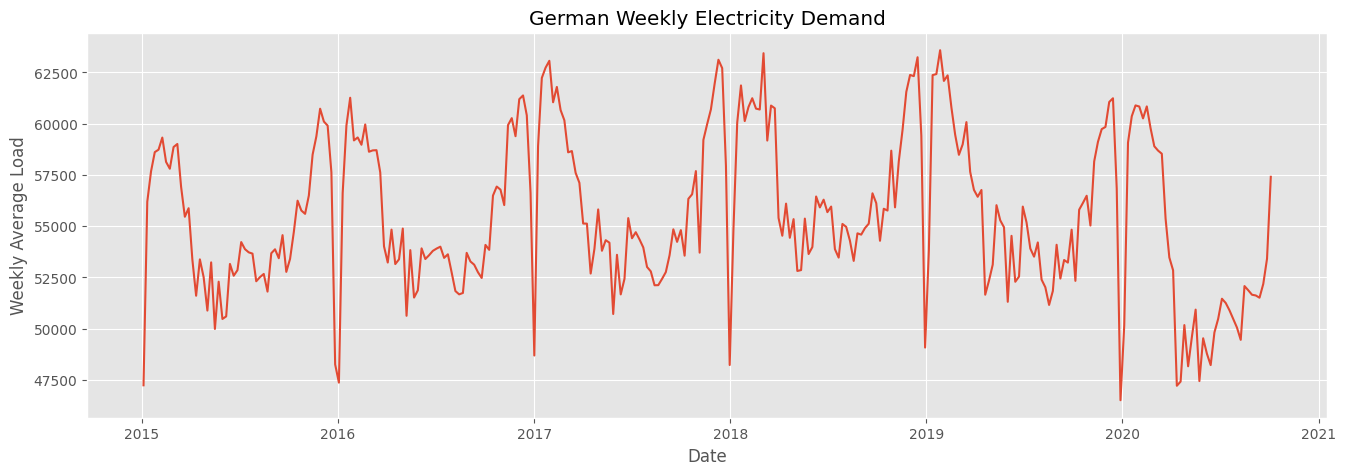

Summary statistics for weekly electricity demand:


,load
count,301.000000
mean,55484.350477
std,3762.742475
min,46505.309524
25%,52845.267857
50%,54858.434524
75%,58688.470238
max,63587.011905


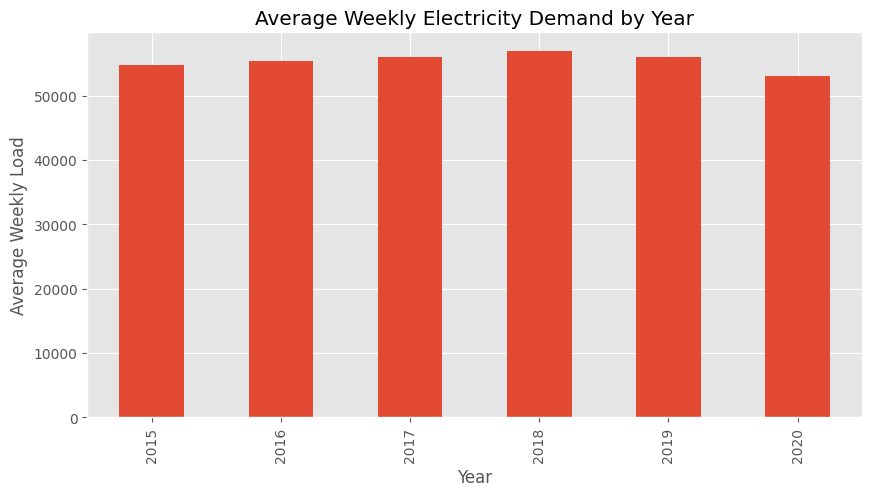

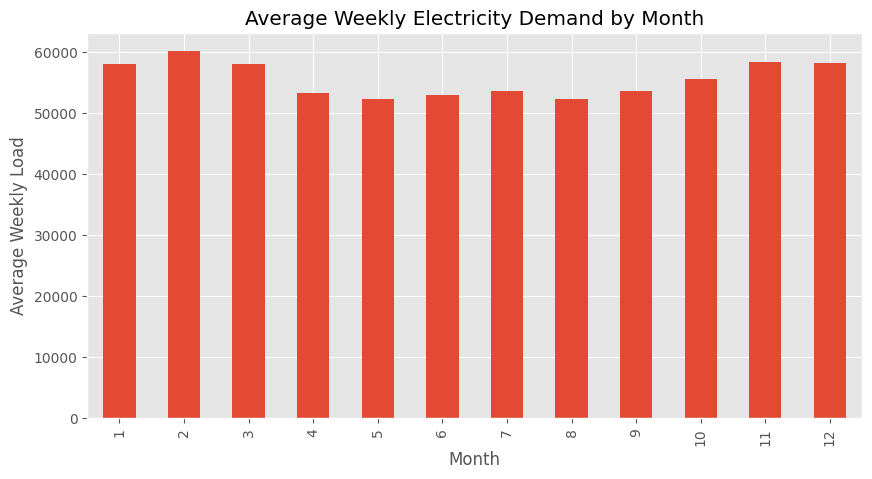

<Figure size 1200x600 with 0 Axes>

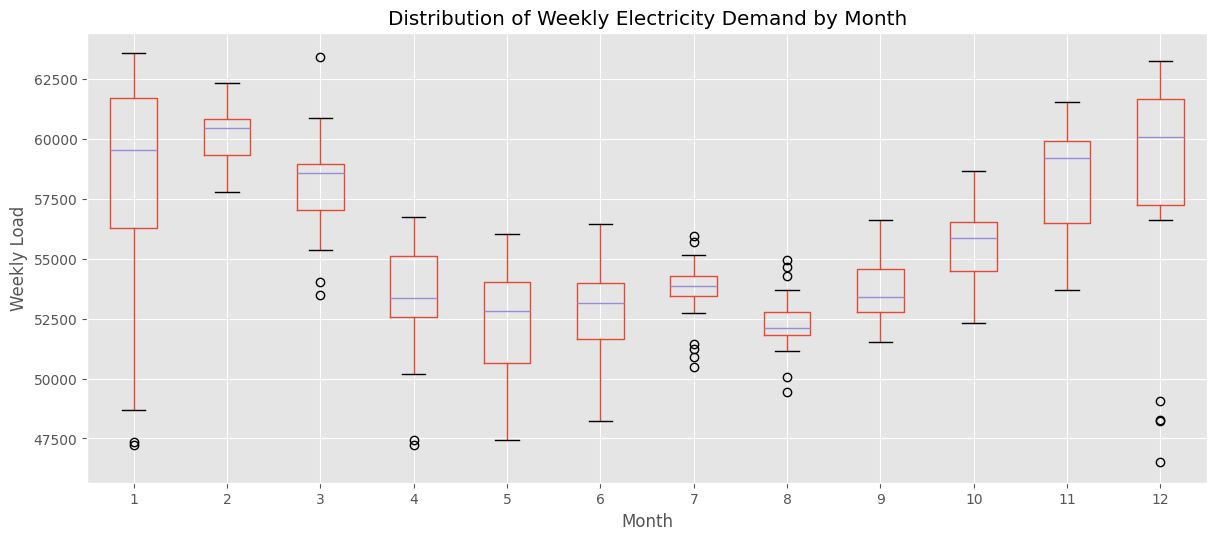

In [ ]:
# ==========================================================
# Part 1 - Initial Time Series Plots and EDA
# ==========================================================

# Hourly electricity demand plot
plt.figure(figsize=(16, 5))
plt.plot(data.index, data["load"])
plt.title("German Hourly Electricity Demand")
plt.xlabel("Date")
plt.ylabel("Electricity Load")
plt.grid(True)
plt.savefig("hourly_load.png", dpi=300, bbox_inches="tight")
plt.show()

# Daily electricity demand plot
plt.figure(figsize=(16, 5))
plt.plot(daily_data.index, daily_data["load"])
plt.title("German Daily Electricity Demand")
plt.xlabel("Date")
plt.ylabel("Daily Average Load")
plt.grid(True)
plt.savefig("daily_load.png", dpi=300, bbox_inches="tight")
plt.show()

# Weekly electricity demand plot
plt.figure(figsize=(16, 5))
plt.plot(weekly_data.index, weekly_data["load"])
plt.title("German Weekly Electricity Demand")
plt.xlabel("Date")
plt.ylabel("Weekly Average Load")
plt.grid(True)
plt.savefig("weekly_load.png", dpi=300, bbox_inches="tight")
plt.show()

# Summary statistics for weekly data
print("Summary statistics for weekly electricity demand:")

summary_stats = weekly_data.describe()

display(summary_stats)

# Save summary statistics to CSV
summary_stats.to_csv("summary_statistics.csv", index=True)

# Add time-based columns for EDA
weekly_eda = weekly_data.copy()
weekly_eda["year"] = weekly_eda.index.year
weekly_eda["month"] = weekly_eda.index.month
weekly_eda["week"] = weekly_eda.index.isocalendar().week.astype(int)

# Average demand by year
plt.figure(figsize=(10, 5))
weekly_eda.groupby("year")["load"].mean().plot(kind="bar")
plt.title("Average Weekly Electricity Demand by Year")
plt.xlabel("Year")
plt.ylabel("Average Weekly Load")
plt.grid(True)
plt.show()

# Average demand by month
plt.figure(figsize=(10, 5))
weekly_eda.groupby("month")["load"].mean().plot(kind="bar")
plt.title("Average Weekly Electricity Demand by Month")
plt.xlabel("Month")
plt.ylabel("Average Weekly Load")
plt.grid(True)
plt.show()

# Boxplot by month to inspect seasonality
plt.figure(figsize=(12, 6))
weekly_eda.boxplot(column="load", by="month")
plt.title("Distribution of Weekly Electricity Demand by Month")
plt.suptitle("")
plt.xlabel("Month")
plt.ylabel("Weekly Load")
plt.grid(True)
plt.show()

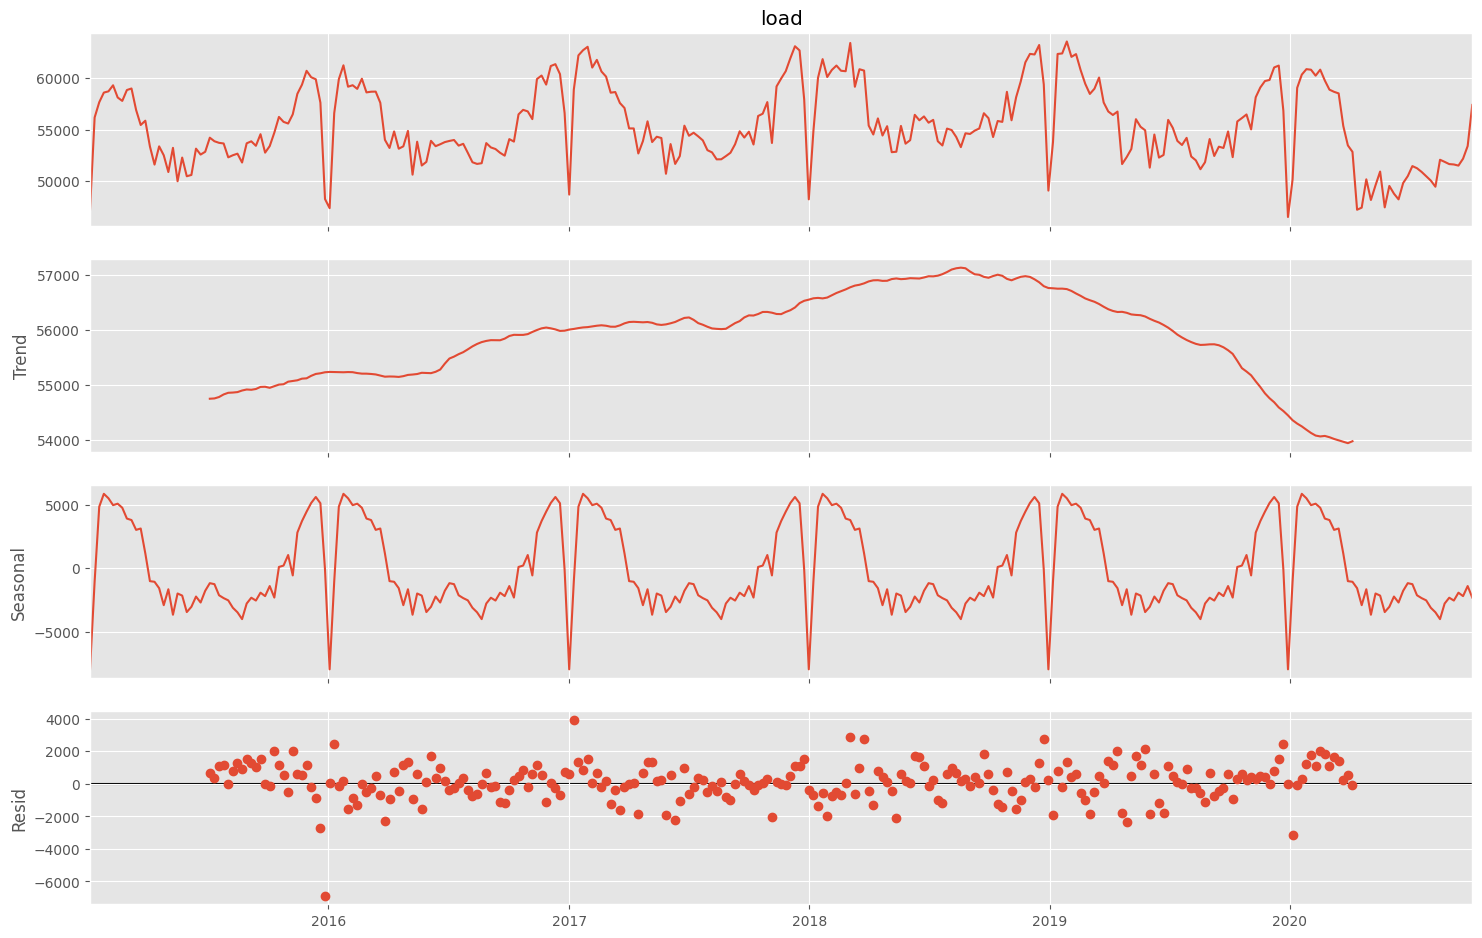

<Figure size 1200x500 with 0 Axes>

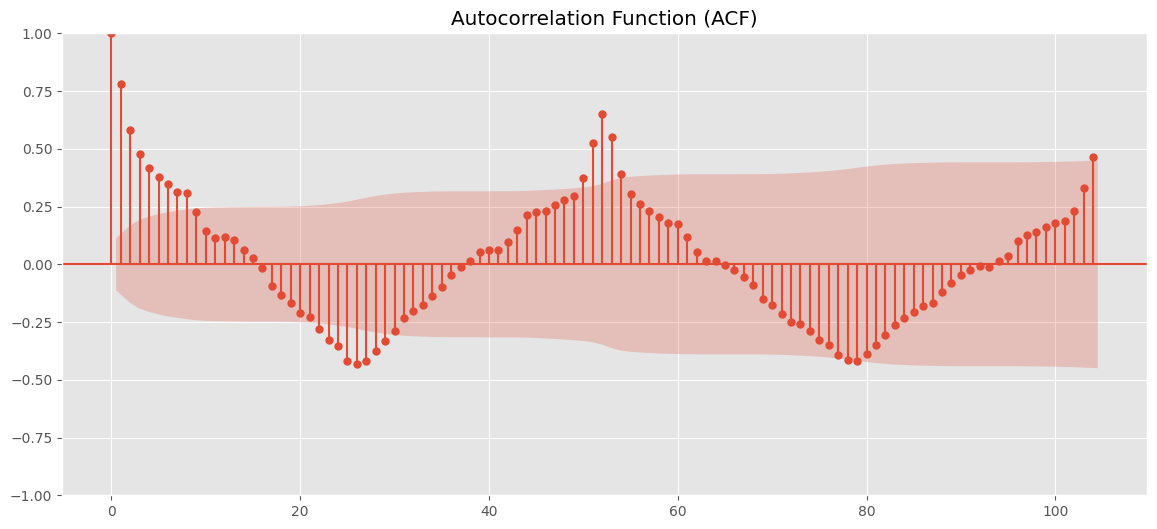

<Figure size 1200x500 with 0 Axes>

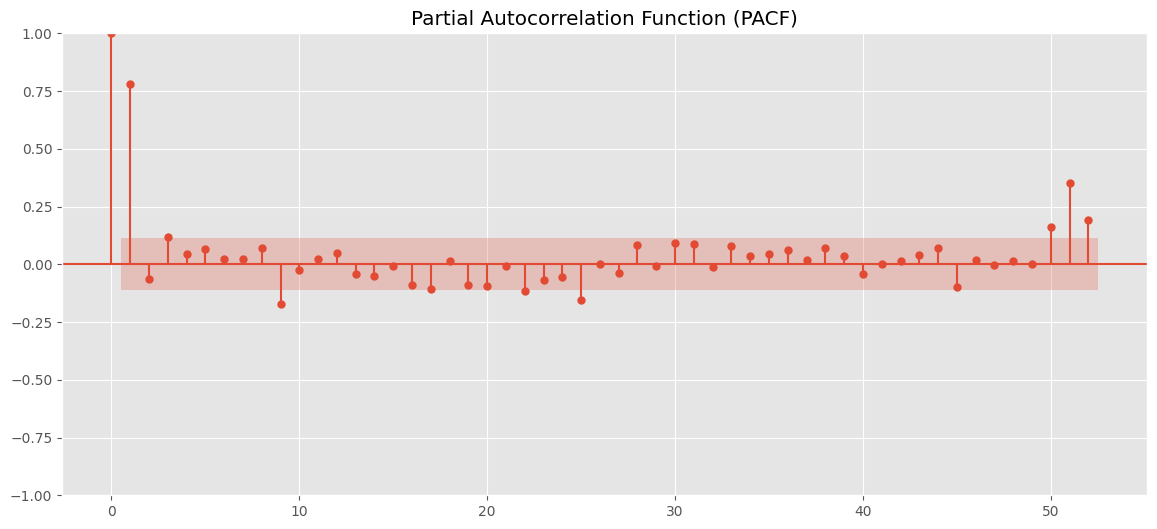

ADF TEST
ADF Statistic : -4.0475
P-value       : 0.0012
Critical Value (1%) : -3.4529
Critical Value (5%) : -2.8715
Critical Value (10%) : -2.5721

Result: Series is Stationary


KPSS TEST
KPSS Statistic : 0.1604
P-value        : 0.1000
Critical Value (10%) : 0.347
Critical Value (5%) : 0.463
Critical Value (2.5%) : 0.574
Critical Value (1%) : 0.739

Result: Series is Stationary


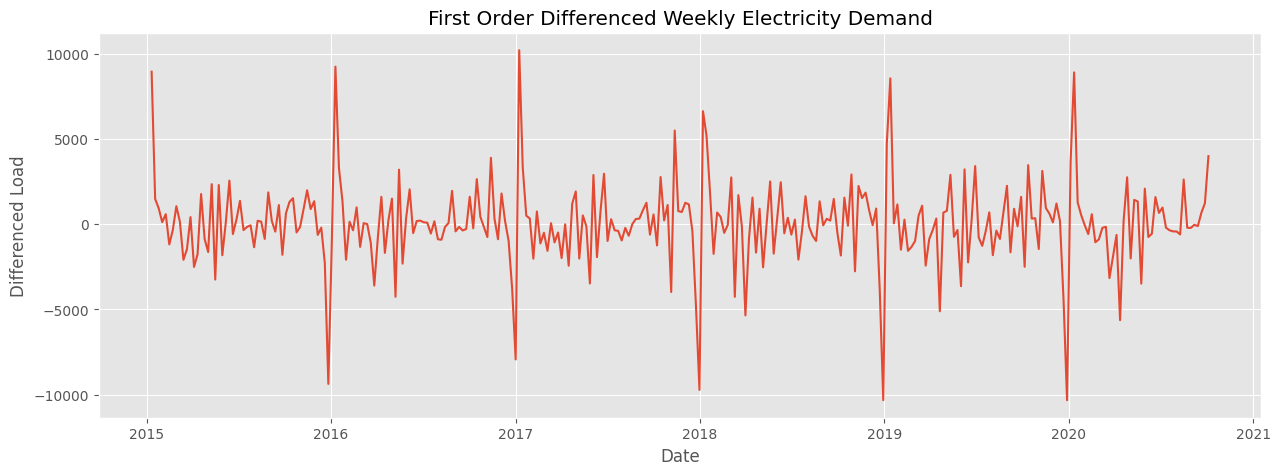

ADF TEST AFTER DIFFERENCING
ADF Statistic : -7.0693
P-value       : 0.0000

Differenced series is Stationary


In [ ]:
# ==========================================================
# Part 1 - Time Series Decomposition & Stationarity Analysis
# ==========================================================

from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.tsa.stattools import adfuller, kpss

# -----------------------------
# Seasonal Decomposition
# -----------------------------

decomposition = seasonal_decompose(
    weekly_data["load"],
    model="additive",
    period=52
)

fig = decomposition.plot()
fig.set_size_inches(15,10)

plt.savefig("seasonal_decomposition.png", dpi=300, bbox_inches="tight")

plt.show()

# -----------------------------
# ACF Plot
# -----------------------------

plt.figure(figsize=(12,5))
plot_acf(weekly_data["load"], lags=104)
plt.title("Autocorrelation Function (ACF)")

plt.savefig("acf_plot.png", dpi=300, bbox_inches="tight")

plt.show()

# -----------------------------
# PACF Plot
# -----------------------------

plt.figure(figsize=(12,5))
plot_pacf(
    weekly_data["load"],
    lags=52,
    method="ywm"
)
plt.title("Partial Autocorrelation Function (PACF)")

plt.savefig("pacf_plot.png", dpi=300, bbox_inches="tight")

plt.show()

# ==========================================================
# Stationarity Tests
# ==========================================================

print("="*60)
print("ADF TEST")
print("="*60)

adf_result = adfuller(weekly_data["load"])

print(f"ADF Statistic : {adf_result[0]:.4f}")
print(f"P-value       : {adf_result[1]:.4f}")

for key, value in adf_result[4].items():
    print(f"Critical Value ({key}) : {value:.4f}")

if adf_result[1] < 0.05:
    print("\nResult: Series is Stationary")
else:
    print("\nResult: Series is NOT Stationary")

print("\n")

print("="*60)
print("KPSS TEST")
print("="*60)

kpss_result = kpss(
    weekly_data["load"],
    regression="c",
    nlags="auto"
)

print(f"KPSS Statistic : {kpss_result[0]:.4f}")
print(f"P-value        : {kpss_result[1]:.4f}")

for key, value in kpss_result[3].items():
    print(f"Critical Value ({key}) : {value}")

if kpss_result[1] > 0.05:
    print("\nResult: Series is Stationary")
else:
    print("\nResult: Series is NOT Stationary")

# ==========================================================
# First Differencing
# ==========================================================

weekly_diff = weekly_data["load"].diff().dropna()

plt.figure(figsize=(15,5))
plt.plot(weekly_diff)
plt.title("First Order Differenced Weekly Electricity Demand")
plt.xlabel("Date")
plt.ylabel("Differenced Load")
plt.grid(True)
plt.show()

# -----------------------------
# ADF After Differencing
# -----------------------------

print("="*60)
print("ADF TEST AFTER DIFFERENCING")
print("="*60)

adf_diff = adfuller(weekly_diff)

print(f"ADF Statistic : {adf_diff[0]:.4f}")
print(f"P-value       : {adf_diff[1]:.4f}")

if adf_diff[1] < 0.05:
    print("\nDifferenced series is Stationary")
else:
    print("\nDifferenced series is NOT Stationary")

Training period:
2015-01-04 00:00:00+00:00 to 2018-10-07 00:00:00+00:00

Testing period:
2018-10-14 00:00:00+00:00 to 2020-10-04 00:00:00+00:00

Training observations: 197
Testing observations: 104


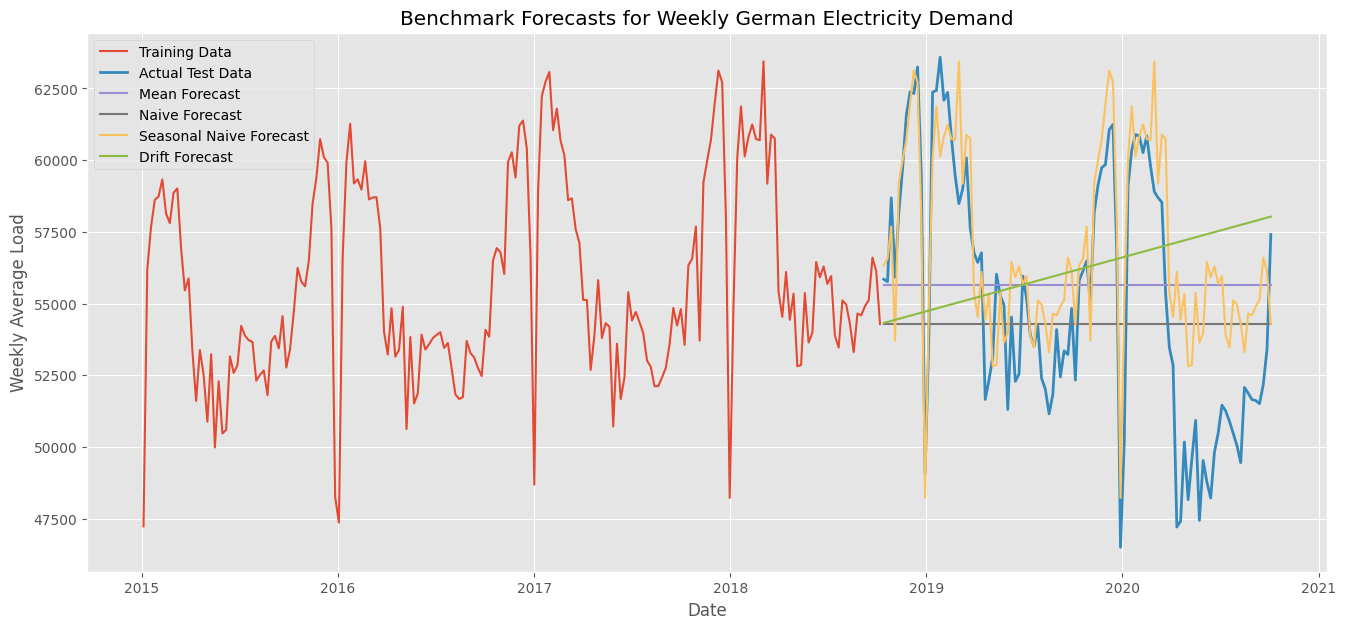

Benchmark Model Performance:


,Model,RMSE,MAE,MAPE
2,Seasonal Naive,3006.760812,2318.520585,4.408920
0,Mean,4397.299694,3788.833122,6.969238
1,Naive,4459.108546,3783.202934,6.790082
3,Drift,5117.957264,4339.890674,8.049685


In [ ]:
# ==========================================================
# Part 2 - Benchmark Forecasting Models
# ==========================================================

from sklearn.metrics import mean_squared_error, mean_absolute_error

# ----------------------------------------------------------
# Evaluation functions
# ----------------------------------------------------------

def rmse(y_true, y_pred):
    return np.sqrt(mean_squared_error(y_true, y_pred))

def mae(y_true, y_pred):
    return mean_absolute_error(y_true, y_pred)

def mape(y_true, y_pred):
    return np.mean(np.abs((y_true - y_pred) / y_true)) * 100


# ----------------------------------------------------------
# Train-test split
# Forecast horizon = last 2 years = approximately 104 weeks
# ----------------------------------------------------------

forecast_horizon = 104

weekly_series = weekly_data["load"].copy()

train = weekly_series.iloc[:-forecast_horizon]
test = weekly_series.iloc[-forecast_horizon:]

print("Training period:")
print(train.index.min(), "to", train.index.max())

print("\nTesting period:")
print(test.index.min(), "to", test.index.max())

print("\nTraining observations:", len(train))
print("Testing observations:", len(test))


# ----------------------------------------------------------
# Benchmark Model 1: Mean Forecast
# ----------------------------------------------------------

mean_forecast = pd.Series(
    train.mean(),
    index=test.index
)


# ----------------------------------------------------------
# Benchmark Model 2: Naive Forecast
# Forecast is equal to the last observed training value
# ----------------------------------------------------------

naive_forecast = pd.Series(
    train.iloc[-1],
    index=test.index
)


# ----------------------------------------------------------
# Benchmark Model 3: Seasonal Naive Forecast
# Weekly data has annual seasonality, so seasonal period = 52
# ----------------------------------------------------------

seasonal_period = 52

seasonal_naive_values = []

for i in range(len(test)):
    value = train.iloc[-seasonal_period + (i % seasonal_period)]
    seasonal_naive_values.append(value)

seasonal_naive_forecast = pd.Series(
    seasonal_naive_values,
    index=test.index
)


# ----------------------------------------------------------
# Benchmark Model 4: Drift Forecast
# Adds a linear trend from first to last training observation
# ----------------------------------------------------------

n = len(train)
first_value = train.iloc[0]
last_value = train.iloc[-1]

drift_values = []

for h in range(1, forecast_horizon + 1):
    drift_value = last_value + h * ((last_value - first_value) / (n - 1))
    drift_values.append(drift_value)

drift_forecast = pd.Series(
    drift_values,
    index=test.index
)


# ----------------------------------------------------------
# Plot benchmark forecasts
# ----------------------------------------------------------

plt.figure(figsize=(16, 7))

plt.plot(train.index, train, label="Training Data")
plt.plot(test.index, test, label="Actual Test Data", linewidth=2)

plt.plot(test.index, mean_forecast, label="Mean Forecast")
plt.plot(test.index, naive_forecast, label="Naive Forecast")
plt.plot(test.index, seasonal_naive_forecast, label="Seasonal Naive Forecast")
plt.plot(test.index, drift_forecast, label="Drift Forecast")

plt.title("Benchmark Forecasts for Weekly German Electricity Demand")
plt.xlabel("Date")
plt.ylabel("Weekly Average Load")
plt.legend()
plt.grid(True)
plt.savefig("benchmark_forecast.png", dpi=300, bbox_inches="tight")
plt.show()


# ----------------------------------------------------------
# Evaluation table
# ----------------------------------------------------------

benchmark_results = pd.DataFrame({
    "Model": [
        "Mean",
        "Naive",
        "Seasonal Naive",
        "Drift"
    ],
    "RMSE": [
        rmse(test, mean_forecast),
        rmse(test, naive_forecast),
        rmse(test, seasonal_naive_forecast),
        rmse(test, drift_forecast)
    ],
    "MAE": [
        mae(test, mean_forecast),
        mae(test, naive_forecast),
        mae(test, seasonal_naive_forecast),
        mae(test, drift_forecast)
    ],
    "MAPE": [
        mape(test, mean_forecast),
        mape(test, naive_forecast),
        mape(test, seasonal_naive_forecast),
        mape(test, drift_forecast)
    ]
})

benchmark_results = benchmark_results.sort_values("RMSE")

print("Benchmark Model Performance:")
display(benchmark_results)

In [ ]:
# ==========================================================
# Save Benchmark Results
# ==========================================================

# Store benchmark metrics for later comparison
results = benchmark_results.copy()

print("Benchmark results saved successfully.")
display(results)

Benchmark results saved successfully.


,Model,RMSE,MAE,MAPE
2,Seasonal Naive,3006.760812,2318.520585,4.408920
0,Mean,4397.299694,3788.833122,6.969238
1,Naive,4459.108546,3783.202934,6.790082
3,Drift,5117.957264,4339.890674,8.049685


In [ ]:
%whos

Variable                  Type               Data/Info
------------------------------------------------------
SARIMAX                   type               <class 'statsmodels.tsa.s<...>tespace.sarimax.SARIMAX'>
adf_diff                  tuple              n=6
adf_result                tuple              n=6
adfuller                  function           <function adfuller at 0x7f60f00d2520>
benchmark_results         DataFrame                      Model        <...>64  4339.890674  8.049685
daily_data                DataFrame                                   <...>\n[2100 rows x 1 columns]
data                      DataFrame                                   <...>n[50400 rows x 1 columns]
decomposition             DecomposeResult    <statsmodels.tsa.seasonal<...>object at 0x7f612f018f20>
df                        DataFrame                            utc_tim<...>50401 rows x 300 columns]
drift_forecast            Series             datetime\n2018-10-14 00:0<...>ngth: 104, dtype: float64
dr

In [ ]:
# ==========================================================
# RECOVERY CELL
# Recreate data, weekly_data, train, test, and benchmark_results
# ==========================================================

!pip -q install pmdarima holidays

import warnings
warnings.filterwarnings("ignore")

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.metrics import mean_squared_error, mean_absolute_error

# Download data again
url = "https://data.open-power-system-data.org/time_series/2020-10-06/time_series_60min_singleindex.csv"

df = pd.read_csv(url, parse_dates=["utc_timestamp"])

# Select German load
data = df[["utc_timestamp", "DE_load_actual_entsoe_transparency"]].copy()

data = data.rename(columns={
    "utc_timestamp": "datetime",
    "DE_load_actual_entsoe_transparency": "load"
})

data = data.set_index("datetime")
data = data.loc["2015-01-01":]
data = data.dropna()

# Daily and weekly data
daily_data = data.resample("D").mean()
weekly_data = data.resample("W").mean()

# Train/test split
forecast_horizon = 104

weekly_series = weekly_data["load"].copy()

train = weekly_series.iloc[:-forecast_horizon]
test = weekly_series.iloc[-forecast_horizon:]

# Metrics
def rmse(y_true, y_pred):
    return np.sqrt(mean_squared_error(y_true, y_pred))

def mae(y_true, y_pred):
    return mean_absolute_error(y_true, y_pred)

def mape(y_true, y_pred):
    return np.mean(np.abs((y_true - y_pred) / y_true)) * 100

# Benchmark models
mean_forecast = pd.Series(train.mean(), index=test.index)
naive_forecast = pd.Series(train.iloc[-1], index=test.index)

seasonal_period = 52
seasonal_naive_values = []

for i in range(len(test)):
    seasonal_naive_values.append(train.iloc[-seasonal_period + (i % seasonal_period)])

seasonal_naive_forecast = pd.Series(seasonal_naive_values, index=test.index)

n = len(train)
first_value = train.iloc[0]
last_value = train.iloc[-1]

drift_values = []

for h in range(1, forecast_horizon + 1):
    drift_value = last_value + h * ((last_value - first_value) / (n - 1))
    drift_values.append(drift_value)

drift_forecast = pd.Series(drift_values, index=test.index)

benchmark_results = pd.DataFrame({
    "Model": ["Mean", "Naive", "Seasonal Naive", "Drift"],
    "RMSE": [
        rmse(test, mean_forecast),
        rmse(test, naive_forecast),
        rmse(test, seasonal_naive_forecast),
        rmse(test, drift_forecast)
    ],
    "MAE": [
        mae(test, mean_forecast),
        mae(test, naive_forecast),
        mae(test, seasonal_naive_forecast),
        mae(test, drift_forecast)
    ],
    "MAPE": [
        mape(test, mean_forecast),
        mape(test, naive_forecast),
        mape(test, seasonal_naive_forecast),
        mape(test, drift_forecast)
    ]
})

print("Recovery complete.")
print("Hourly data:", data.shape)
print("Daily data:", daily_data.shape)
print("Weekly data:", weekly_data.shape)
print("Train:", len(train))
print("Test:", len(test))

display(benchmark_results)

Recovery complete.
Hourly data: (50400, 1)
Daily data: (2100, 1)
Weekly data: (301, 1)
Train: 197
Test: 104


,Model,RMSE,MAE,MAPE
0,Mean,4397.299694,3788.833122,6.969238
1,Naive,4459.108546,3783.202934,6.790082
2,Seasonal Naive,3006.760812,2318.520585,4.408920
3,Drift,5117.957264,4339.890674,8.049685


In [ ]:
# ==========================================================
# PART 3 - SARIMA
# Required p,d,q Grid Search using AIC
# p = 0-6, d = 0-2, q = 0-6
# ==========================================================

import itertools
import numpy as np
import pandas as pd
from statsmodels.tsa.statespace.sarimax import SARIMAX

forecast_horizon = 104

weekly_series = weekly_data["load"].copy()

train = weekly_series.iloc[:-forecast_horizon]
test = weekly_series.iloc[-forecast_horizon:]

p_values = range(0, 7)
d_values = range(0, 3)
q_values = range(0, 7)

# Weekly yearly seasonality = 52
# Seasonal part is kept fixed so that the required p,d,q grid is fully searched.
seasonal_order = (1, 0, 0, 52)

aic_results = []

best_aic = np.inf
best_order = None
best_seasonal_order = seasonal_order

print("Starting SARIMA grid search...")
print("Total p,d,q combinations:", 7 * 3 * 7)

for order in itertools.product(p_values, d_values, q_values):

    try:
        model = SARIMAX(
            train,
            order=order,
            seasonal_order=seasonal_order,
            enforce_stationarity=False,
            enforce_invertibility=False
        )

        fitted_model = model.fit(
            disp=False,
            maxiter=50
        )

        aic = fitted_model.aic

        aic_results.append({
            "order": order,
            "seasonal_order": seasonal_order,
            "AIC": aic
        })

        if aic < best_aic:
            best_aic = aic
            best_order = order

            print("New best model:")
            print("order:", best_order)
            print("seasonal_order:", best_seasonal_order)
            print("AIC:", round(best_aic, 2))
            print("-" * 50)

    except Exception as e:
        continue

sarima_grid_results = pd.DataFrame(aic_results)

sarima_grid_results = sarima_grid_results.sort_values(
    by="AIC"
).reset_index(drop=True)

print("\nTop 10 SARIMA models by AIC:")
display(sarima_grid_results.head(10))

print("\nBest SARIMA order:", best_order)
print("Best seasonal order:", best_seasonal_order)
print("Best AIC:", round(best_aic, 2))

Starting SARIMA grid search...
Total p,d,q combinations: 147
New best model:
order: (0, 0, 0)
seasonal_order: (1, 0, 0, 52)
AIC: 2566.21
--------------------------------------------------
New best model:
order: (0, 1, 1)
seasonal_order: (1, 0, 0, 52)
AIC: 2550.28
--------------------------------------------------
New best model:
order: (1, 1, 0)
seasonal_order: (1, 0, 0, 52)
AIC: 2541.58
--------------------------------------------------
New best model:
order: (1, 1, 1)
seasonal_order: (1, 0, 0, 52)
AIC: 2522.09
--------------------------------------------------
New best model:
order: (1, 1, 2)
seasonal_order: (1, 0, 0, 52)
AIC: 2520.4
--------------------------------------------------
New best model:
order: (2, 1, 0)
seasonal_order: (1, 0, 0, 52)
AIC: 2509.57
--------------------------------------------------
New best model:
order: (2, 1, 1)
seasonal_order: (1, 0, 0, 52)
AIC: 2500.65
--------------------------------------------------
New best model:
order: (2, 2, 2)
seasonal_order: (1

,order,seasonal_order,AIC
0,"(6, 2, 1)","(1, 0, 0, 52)",2434.140674
1,"(6, 1, 1)","(1, 0, 0, 52)",2435.187663
2,"(6, 1, 0)","(1, 0, 0, 52)",2441.853807
3,"(5, 1, 1)","(1, 0, 0, 52)",2449.813974
4,"(5, 2, 1)","(1, 0, 0, 52)",2454.842153
5,"(5, 1, 0)","(1, 0, 0, 52)",2456.907015
6,"(6, 1, 2)","(1, 0, 0, 52)",2460.426833
7,"(6, 2, 3)","(1, 0, 0, 52)",2462.738417
8,"(6, 2, 0)","(1, 0, 0, 52)",2463.368719
9,"(6, 1, 3)","(1, 0, 0, 52)",2464.698311



Best SARIMA order: (6, 2, 1)
Best seasonal order: (1, 0, 0, 52)
Best AIC: 2434.14


                                      SARIMAX Results                                      
Dep. Variable:                                load   No. Observations:                  197
Model:             SARIMAX(6, 2, 1)x(1, 0, [], 52)   Log Likelihood               -1208.070
Date:                             Wed, 15 Jul 2026   AIC                           2434.141
Time:                                     16:57:19   BIC                           2460.421
Sample:                                 01-04-2015   HQIC                          2444.820
                                      - 10-07-2018                                         
Covariance Type:                               opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1         -0.6024      0.071     -8.441      0.000      -0.742      -0.463
ar.L2         -0.3361      

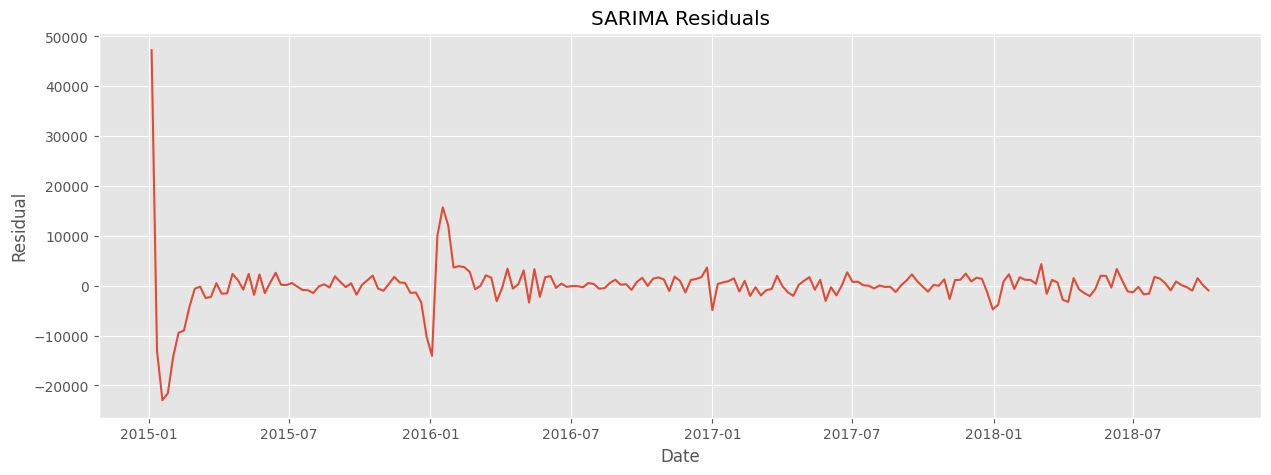

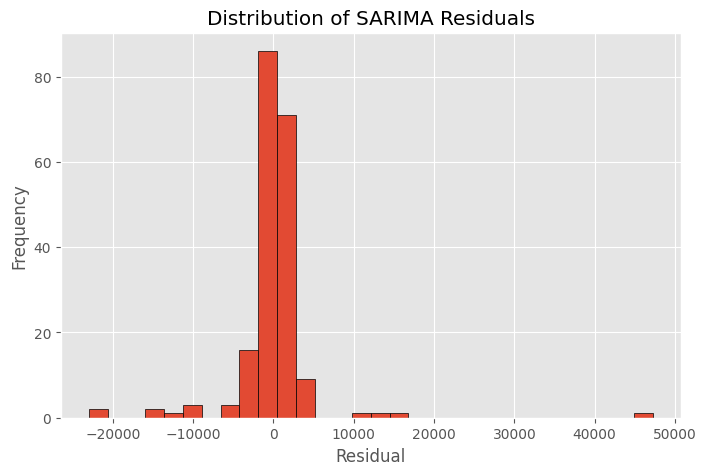

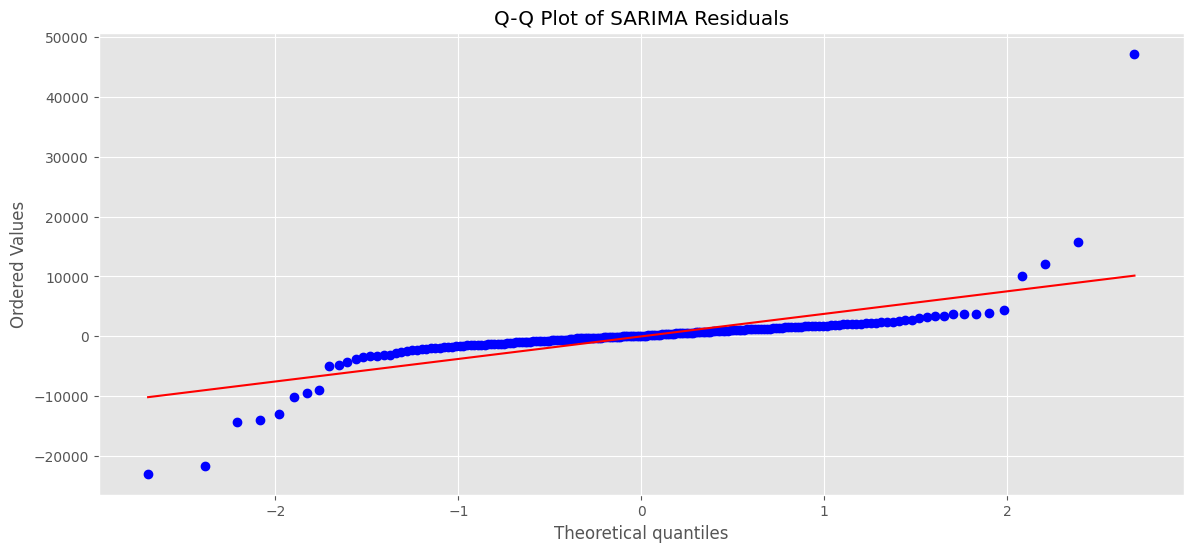

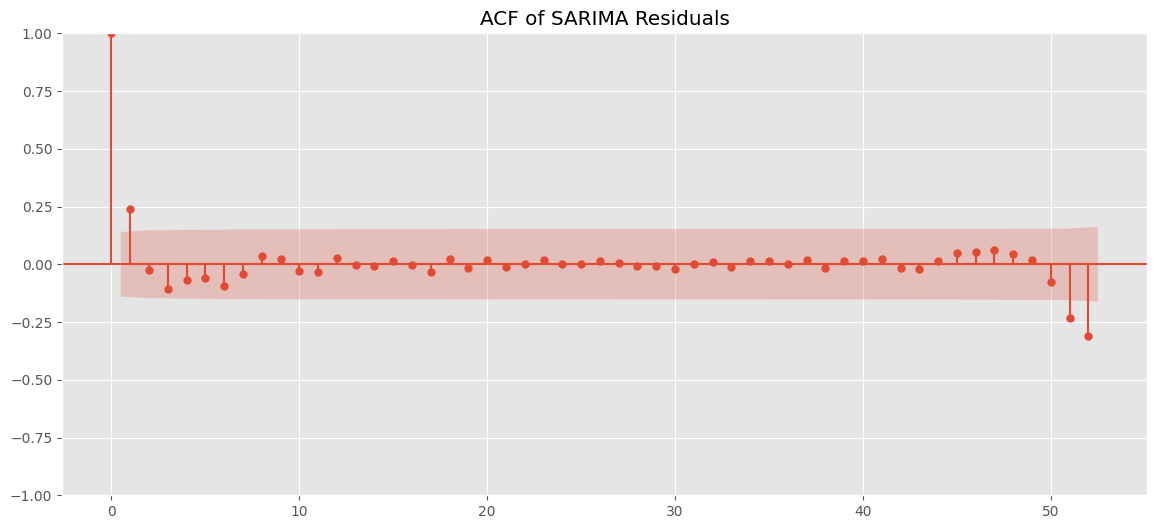

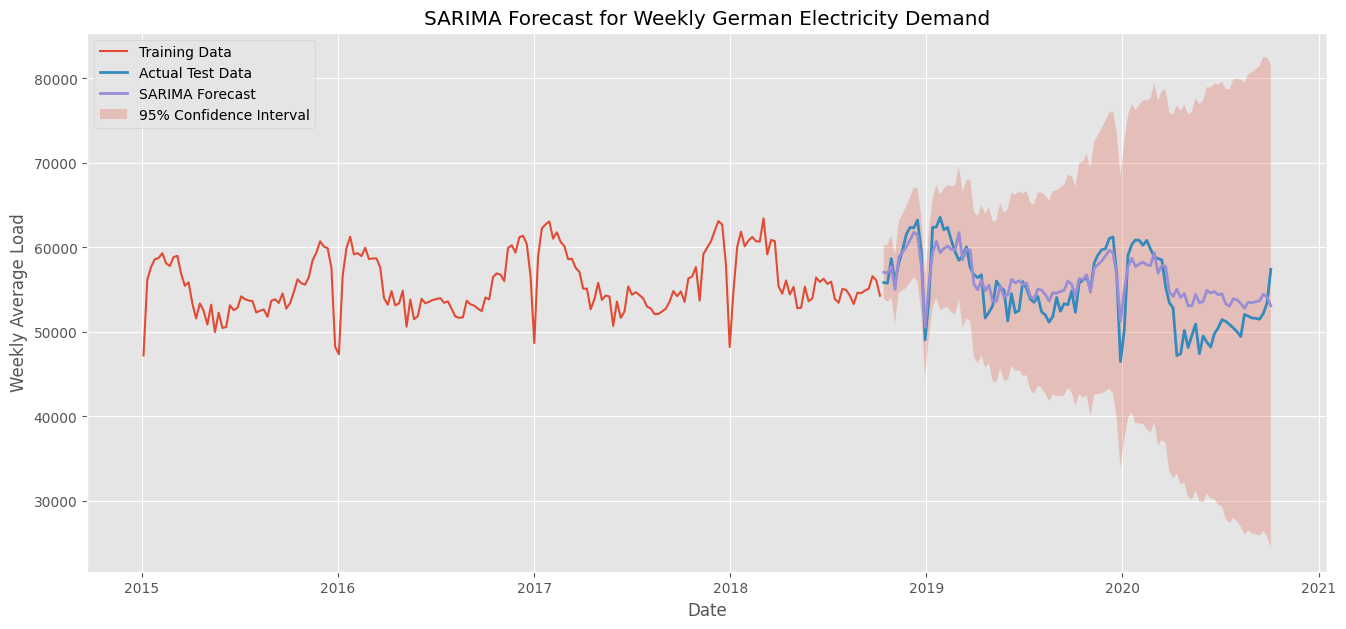

SARIMA Performance:


,Model,RMSE,MAE,MAPE
0,SARIMA,2674.831119,2134.795248,4.02993


Model Comparison So Far:


,Model,RMSE,MAE,MAPE
4,SARIMA,2674.831119,2134.795248,4.029930
2,Seasonal Naive,3006.760812,2318.520585,4.408920
0,Mean,4397.299694,3788.833122,6.969238
1,Naive,4459.108546,3783.202934,6.790082
3,Drift,5117.957264,4339.890674,8.049685


In [ ]:
# ==========================================================
# PART 3 - SARIMA Forecast, Diagnostics and Evaluation
# ==========================================================

from statsmodels.tsa.statespace.sarimax import SARIMAX
from statsmodels.graphics.tsaplots import plot_acf
from scipy import stats

# Fit SARIMA using best parameters
sarima_model = SARIMAX(
    train,
    order=best_order,
    seasonal_order=best_seasonal_order,
    enforce_stationarity=False,
    enforce_invertibility=False
)

sarima_fit = sarima_model.fit(disp=False)

print(sarima_fit.summary())

# Residuals
sarima_residuals = sarima_fit.resid

# Residual plot
plt.figure(figsize=(15, 5))
plt.plot(sarima_residuals)
plt.title("SARIMA Residuals")
plt.xlabel("Date")
plt.ylabel("Residual")
plt.grid(True)
plt.savefig("sarima_residuals.png", dpi=300, bbox_inches="tight")
plt.show()

# Residual distribution
plt.figure(figsize=(8, 5))
plt.hist(sarima_residuals, bins=30, edgecolor="black")
plt.title("Distribution of SARIMA Residuals")
plt.xlabel("Residual")
plt.ylabel("Frequency")
plt.grid(True)
plt.savefig("sarima_residual_histogram.png", dpi=300, bbox_inches="tight")
plt.show()

# Q-Q plot
stats.probplot(sarima_residuals, dist="norm", plot=plt)
plt.title("Q-Q Plot of SARIMA Residuals")
plt.savefig("sarima_qq_plot.png", dpi=300, bbox_inches="tight")
plt.show()

# Residual ACF
plot_acf(sarima_residuals.dropna(), lags=52)
plt.title("ACF of SARIMA Residuals")
plt.savefig("sarima_residual_acf.png", dpi=300, bbox_inches="tight")
plt.show()

# Forecast last 2 years
sarima_forecast_obj = sarima_fit.get_forecast(steps=forecast_horizon)

sarima_forecast = sarima_forecast_obj.predicted_mean
sarima_conf_int = sarima_forecast_obj.conf_int()

sarima_forecast.index = test.index
sarima_conf_int.index = test.index

# Forecast plot
plt.figure(figsize=(16, 7))
plt.plot(train.index, train, label="Training Data")
plt.plot(test.index, test, label="Actual Test Data", linewidth=2)
plt.plot(test.index, sarima_forecast, label="SARIMA Forecast", linewidth=2)

plt.fill_between(
    test.index,
    sarima_conf_int.iloc[:, 0],
    sarima_conf_int.iloc[:, 1],
    alpha=0.25,
    label="95% Confidence Interval"
)

plt.title("SARIMA Forecast for Weekly German Electricity Demand")
plt.xlabel("Date")
plt.ylabel("Weekly Average Load")
plt.legend()
plt.grid(True)
plt.savefig("sarima_forecast.png", dpi=300, bbox_inches="tight")
plt.show()

# Evaluation
sarima_rmse = rmse(test, sarima_forecast)
sarima_mae = mae(test, sarima_forecast)
sarima_mape = mape(test, sarima_forecast)

sarima_result = pd.DataFrame({
    "Model": ["SARIMA"],
    "RMSE": [sarima_rmse],
    "MAE": [sarima_mae],
    "MAPE": [sarima_mape]
})

print("SARIMA Performance:")
display(sarima_result)

# Add to results table
all_results = pd.concat(
    [benchmark_results, sarima_result],
    ignore_index=True
).sort_values("RMSE")

print("Model Comparison So Far:")
display(all_results)

In [ ]:
# ==========================================================
# PART 4 - Download Berlin Temperature Data
# ==========================================================

import pandas as pd

# Open-Meteo archive API (Berlin)
url = (
    "https://archive-api.open-meteo.com/v1/archive?"
    "latitude=52.52&longitude=13.41"
    "&start_date=2015-01-01"
    "&end_date=2020-10-31"
    "&daily=temperature_2m_mean"
    "&timezone=Europe/Berlin"
)

temperature = pd.read_json(url)

# Extract daily data
temperature = pd.DataFrame({
    "date": pd.to_datetime(temperature["daily"]["time"]),
    "temperature": temperature["daily"]["temperature_2m_mean"]
})

temperature = temperature.set_index("date")

# Convert daily temperature to weekly average
weekly_temperature = temperature.resample("W").mean()

print("Weekly Temperature Shape:", weekly_temperature.shape)

display(weekly_temperature.head())

Weekly Temperature Shape: (305, 1)


,temperature
date,
2015-01-04,3.575000
2015-01-11,3.885714
2015-01-18,4.900000
2015-01-25,0.028571
2015-02-01,1.414286


Merged dataset shape: (301, 2)


,load,temperature
2015-01-04,47233.739583,3.575000
2015-01-11,56191.101190,3.885714
2015-01-18,57672.678571,4.900000
2015-01-25,58613.303571,0.028571
2015-02-01,58734.029762,1.414286


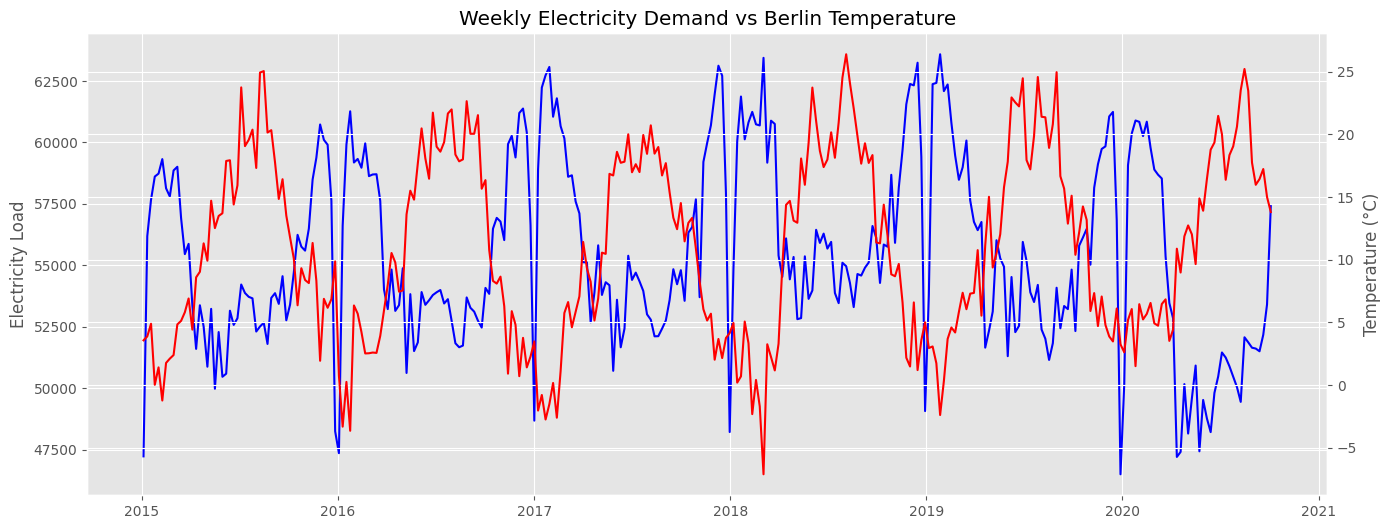


Correlation Matrix


,load,temperature
load,1.000000,-0.637379
temperature,-0.637379,1.000000


In [ ]:
# ==========================================================
# PART 4 - Merge Weekly Electricity Demand with Temperature
# ==========================================================

# Remove timezone from electricity data
weekly_data.index = weekly_data.index.tz_localize(None)

# Remove timezone from temperature data (safe even if already naive)
try:
    weekly_temperature.index = weekly_temperature.index.tz_localize(None)
except:
    pass

# Merge datasets
weekly_features = weekly_data.join(weekly_temperature, how="inner")

# Remove missing values
weekly_features = weekly_features.dropna()

print("Merged dataset shape:", weekly_features.shape)

display(weekly_features.head())

# Plot
fig, ax1 = plt.subplots(figsize=(16,6))

ax1.plot(
    weekly_features.index,
    weekly_features["load"],
    color="blue",
    label="Load"
)

ax1.set_ylabel("Electricity Load")

ax2 = ax1.twinx()

ax2.plot(
    weekly_features.index,
    weekly_features["temperature"],
    color="red",
    label="Temperature"
)

ax2.set_ylabel("Temperature (°C)")

plt.title("Weekly Electricity Demand vs Berlin Temperature")
plt.grid(True)
plt.savefig("temperature_vs_load.png", dpi=300, bbox_inches="tight")
plt.show()

print("\nCorrelation Matrix")
display(weekly_features.corr())

Training observations: 197
Testing observations: 104
                                      SARIMAX Results                                      
Dep. Variable:                                load   No. Observations:                  197
Model:             SARIMAX(6, 2, 1)x(1, 0, [], 52)   Log Likelihood               -1206.801
Date:                             Wed, 15 Jul 2026   AIC                           2433.602
Time:                                     16:57:38   BIC                           2462.802
Sample:                                 01-04-2015   HQIC                          2445.468
                                      - 10-07-2018                                         
Covariance Type:                               opg                                         
                  coef    std err          z      P>|z|      [0.025      0.975]
-------------------------------------------------------------------------------
temperature  -250.6881     47.178     -5.314      0

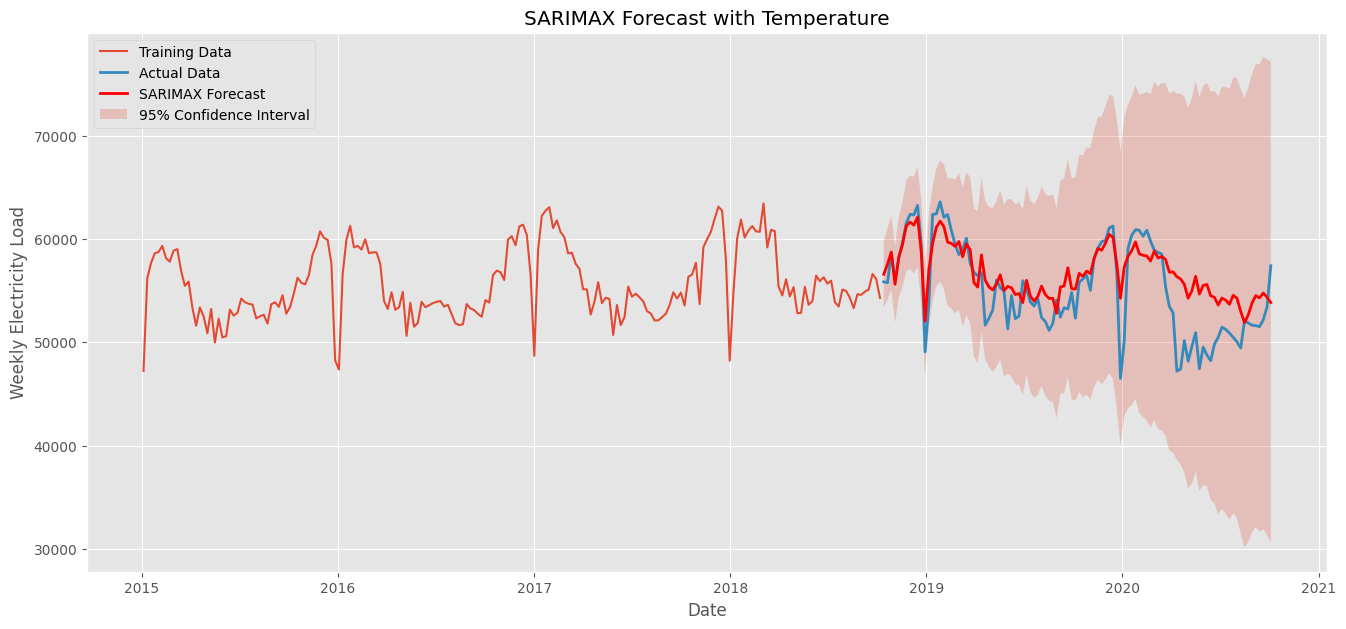


SARIMAX Performance


,Model,RMSE,MAE,MAPE
0,SARIMAX,3055.214233,2266.895399,4.356206



Model Comparison


,Model,RMSE,MAE,MAPE
4,SARIMA,2674.831119,2134.795248,4.029930
2,Seasonal Naive,3006.760812,2318.520585,4.408920
5,SARIMAX,3055.214233,2266.895399,4.356206
0,Mean,4397.299694,3788.833122,6.969238
1,Naive,4459.108546,3783.202934,6.790082
3,Drift,5117.957264,4339.890674,8.049685


In [ ]:
# ==========================================================
# PART 4 - SARIMAX with Temperature
# ==========================================================

from statsmodels.tsa.statespace.sarimax import SARIMAX

# -----------------------------
# Train-Test Split
# -----------------------------

forecast_horizon = 104

train_data = weekly_features.iloc[:-forecast_horizon]
test_data = weekly_features.iloc[-forecast_horizon:]

y_train = train_data["load"]
y_test = test_data["load"]

X_train = train_data[["temperature"]]
X_test = test_data[["temperature"]]

print("Training observations:", len(train_data))
print("Testing observations:", len(test_data))

# -----------------------------
# Build SARIMAX
# -----------------------------

sarimax_model = SARIMAX(
    y_train,
    exog=X_train,
    order=best_order,
    seasonal_order=best_seasonal_order,
    enforce_stationarity=False,
    enforce_invertibility=False
)

sarimax_fit = sarimax_model.fit(disp=False)

print(sarimax_fit.summary())

# -----------------------------
# Forecast
# -----------------------------

sarimax_forecast_obj = sarimax_fit.get_forecast(
    steps=forecast_horizon,
    exog=X_test
)

sarimax_forecast = sarimax_forecast_obj.predicted_mean

sarimax_ci = sarimax_forecast_obj.conf_int()

sarimax_forecast.index = y_test.index
sarimax_ci.index = y_test.index

# -----------------------------
# Plot
# -----------------------------

plt.figure(figsize=(16,7))

plt.plot(
    y_train.index,
    y_train,
    label="Training Data"
)

plt.plot(
    y_test.index,
    y_test,
    label="Actual Data",
    linewidth=2
)

plt.plot(
    y_test.index,
    sarimax_forecast,
    label="SARIMAX Forecast",
    linewidth=2,
    color="red"
)

plt.fill_between(
    y_test.index,
    sarimax_ci.iloc[:,0],
    sarimax_ci.iloc[:,1],
    alpha=0.25,
    label="95% Confidence Interval"
)

plt.title("SARIMAX Forecast with Temperature")
plt.xlabel("Date")
plt.ylabel("Weekly Electricity Load")
plt.legend()
plt.grid(True)
plt.savefig("sarimax_forecast.png", dpi=300, bbox_inches="tight")
plt.show()

# -----------------------------
# Metrics
# -----------------------------

sarimax_rmse = rmse(y_test, sarimax_forecast)
sarimax_mae = mae(y_test, sarimax_forecast)
sarimax_mape = mape(y_test, sarimax_forecast)

sarimax_result = pd.DataFrame({
    "Model":["SARIMAX"],
    "RMSE":[sarimax_rmse],
    "MAE":[sarimax_mae],
    "MAPE":[sarimax_mape]
})

print("\nSARIMAX Performance")
display(sarimax_result)

# -----------------------------
# Compare with previous models
# -----------------------------

comparison = pd.concat(
    [
        benchmark_results,
        sarima_result,
        sarimax_result
    ],
    ignore_index=True
)

comparison = comparison.sort_values("RMSE")

print("\nModel Comparison")
display(comparison)

In [ ]:
# ==========================================================
# PART 5 - Feature Engineering
# ==========================================================

rf_data = weekly_features.copy()

# Calendar features
rf_data["year"] = rf_data.index.year
rf_data["month"] = rf_data.index.month
rf_data["week"] = rf_data.index.isocalendar().week.astype(int)

# Lag features
rf_data["lag_1"] = rf_data["load"].shift(1)
rf_data["lag_2"] = rf_data["load"].shift(2)
rf_data["lag_52"] = rf_data["load"].shift(52)

# Rolling averages
rf_data["rolling_mean_4"] = rf_data["load"].shift(1).rolling(4).mean()
rf_data["rolling_mean_12"] = rf_data["load"].shift(1).rolling(12).mean()

# Remove rows with NaN values
rf_data = rf_data.dropna()

print("Feature dataset shape:", rf_data.shape)

display(rf_data.head())

Feature dataset shape: (249, 10)


,load,temperature,year,month,week,lag_1,lag_2,lag_52,rolling_mean_4,rolling_mean_12
2016-01-03,47364.035714,0.757143,2016,1,53,48253.363095,57627.857143,47233.739583,56473.808036,56943.477679
2016-01-10,56615.142857,-3.314286,2016,1,1,47364.035714,48253.363095,56191.101190,53288.147321,56330.935020
2016-01-17,59913.910714,0.257143,2016,1,2,56615.142857,47364.035714,57672.678571,52465.099702,56361.866071
2016-01-24,61267.529762,-3.642857,2016,1,3,59913.910714,56615.142857,58613.303571,53036.613095,56707.694940
2016-01-31,59185.089286,6.357143,2016,1,4,61267.529762,59913.910714,58734.029762,56290.154762,57179.856647


Training observations: 145
Testing observations: 104

Random Forest Performance


,Model,RMSE,MAE,MAPE
0,Random Forest,2688.138969,1981.349135,3.816028


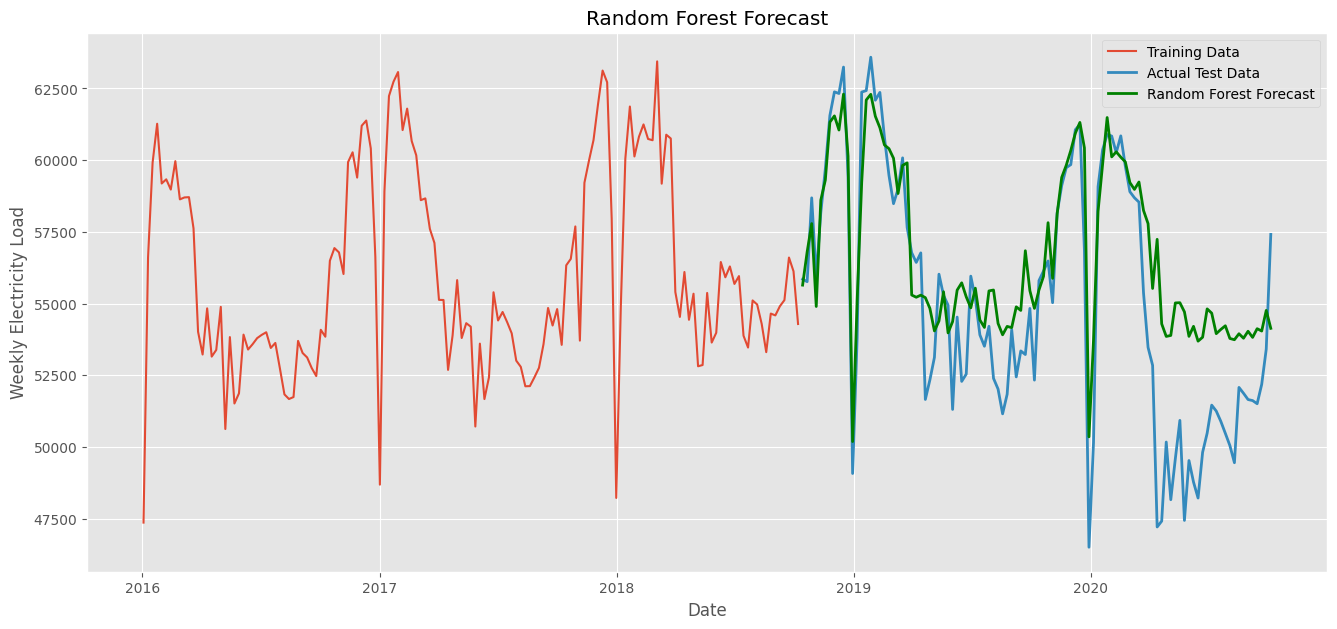

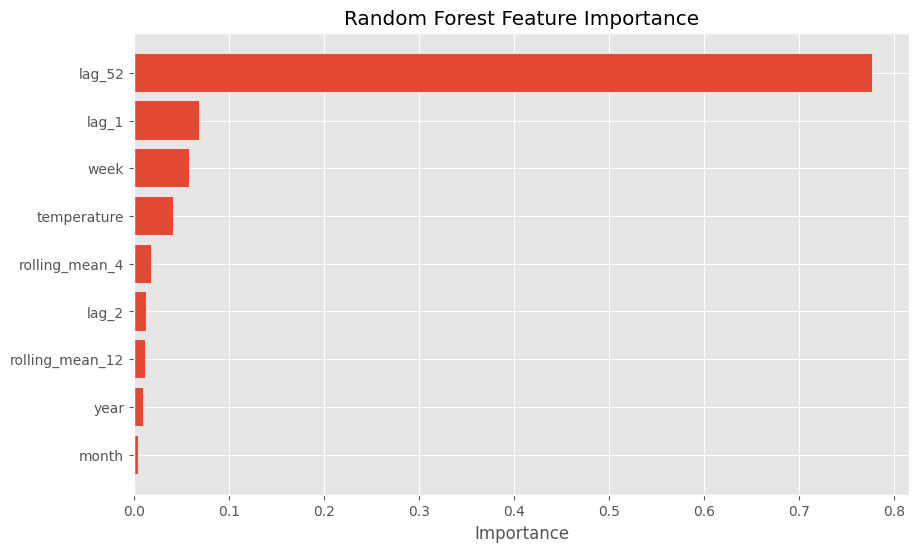


Overall Model Comparison


,Model,RMSE,MAE,MAPE
4,SARIMA,2674.831119,2134.795248,4.029930
6,Random Forest,2688.138969,1981.349135,3.816028
2,Seasonal Naive,3006.760812,2318.520585,4.408920
5,SARIMAX,3055.214233,2266.895399,4.356206
0,Mean,4397.299694,3788.833122,6.969238
1,Naive,4459.108546,3783.202934,6.790082
3,Drift,5117.957264,4339.890674,8.049685


In [ ]:
# ==========================================================
# PART 5 - Random Forest Regression
# ==========================================================

from sklearn.ensemble import RandomForestRegressor

# -----------------------------
# Features and Target
# -----------------------------

X = rf_data.drop(columns=["load"])
y = rf_data["load"]

# Last 104 weeks for testing
forecast_horizon = 104

X_train = X.iloc[:-forecast_horizon]
X_test = X.iloc[-forecast_horizon:]

y_train = y.iloc[:-forecast_horizon]
y_test = y.iloc[-forecast_horizon:]

print("Training observations:", len(X_train))
print("Testing observations:", len(X_test))

# -----------------------------
# Train Random Forest
# -----------------------------

rf_model = RandomForestRegressor(
    n_estimators=300,
    max_depth=10,
    random_state=42,
    n_jobs=-1
)

rf_model.fit(X_train, y_train)

# -----------------------------
# Prediction
# -----------------------------

rf_predictions = rf_model.predict(X_test)

# -----------------------------
# Metrics
# -----------------------------

rf_rmse = rmse(y_test, rf_predictions)
rf_mae = mae(y_test, rf_predictions)
rf_mape = mape(y_test, rf_predictions)

rf_result = pd.DataFrame({
    "Model":["Random Forest"],
    "RMSE":[rf_rmse],
    "MAE":[rf_mae],
    "MAPE":[rf_mape]
})

print("\nRandom Forest Performance")
display(rf_result)

# -----------------------------
# Forecast Plot
# -----------------------------

plt.figure(figsize=(16,7))

plt.plot(
    y_train.index,
    y_train,
    label="Training Data"
)

plt.plot(
    y_test.index,
    y_test,
    label="Actual Test Data",
    linewidth=2
)

plt.plot(
    y_test.index,
    rf_predictions,
    label="Random Forest Forecast",
    linewidth=2,
    color="green"
)

plt.title("Random Forest Forecast")
plt.xlabel("Date")
plt.ylabel("Weekly Electricity Load")
plt.legend()
plt.grid(True)
plt.savefig("random_forest_forecast.png", dpi=300, bbox_inches="tight")
plt.show()

# -----------------------------
# Feature Importance
# -----------------------------

importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": rf_model.feature_importances_
})

importance = importance.sort_values(
    "Importance",
    ascending=False
)

plt.figure(figsize=(10,6))
plt.barh(
    importance["Feature"],
    importance["Importance"]
)

plt.title("Random Forest Feature Importance")
plt.xlabel("Importance")
plt.gca().invert_yaxis()
plt.show()

# -----------------------------
# Update Comparison Table
# -----------------------------

comparison = pd.concat(
    [
        benchmark_results,
        sarima_result,
        sarimax_result,
        rf_result
    ],
    ignore_index=True
)

comparison = comparison.sort_values("RMSE")

print("\nOverall Model Comparison")
display(comparison)

In [ ]:
# ==========================================================
# PART 6 - LSTM
# Prepare Hourly Data
# ==========================================================

from sklearn.preprocessing import MinMaxScaler

# Use hourly electricity demand
hourly_data = data[["load"]].copy()
hourly_data = hourly_data.dropna()

# Last 2 years as test set
forecast_horizon_hours = 24 * 365 * 2

train_hourly = hourly_data.iloc[:-forecast_horizon_hours]
test_hourly = hourly_data.iloc[-forecast_horizon_hours:]

print("Training hourly observations:", len(train_hourly))
print("Testing hourly observations:", len(test_hourly))

# Scale data
scaler = MinMaxScaler()

train_scaled = scaler.fit_transform(train_hourly)
test_scaled = scaler.transform(test_hourly)

# Create sequences
def create_sequences(data_array, window_size):
    X = []
    y = []

    for i in range(window_size, len(data_array)):
        X.append(data_array[i-window_size:i, 0])
        y.append(data_array[i, 0])

    return np.array(X), np.array(y)

# Use previous 7 days to predict next hour
window_size = 24 * 7

X_train_lstm, y_train_lstm = create_sequences(train_scaled, window_size)
X_test_lstm, y_test_lstm = create_sequences(test_scaled, window_size)

# Reshape for LSTM: samples, timesteps, features
X_train_lstm = X_train_lstm.reshape(
    X_train_lstm.shape[0],
    X_train_lstm.shape[1],
    1
)

X_test_lstm = X_test_lstm.reshape(
    X_test_lstm.shape[0],
    X_test_lstm.shape[1],
    1
)

print("X_train shape:", X_train_lstm.shape)
print("y_train shape:", y_train_lstm.shape)
print("X_test shape:", X_test_lstm.shape)
print("y_test shape:", y_test_lstm.shape)

Training hourly observations: 32880
Testing hourly observations: 17520
X_train shape: (32712, 168, 1)
y_train shape: (32712,)
X_test shape: (17352, 168, 1)
y_test shape: (17352,)


In [ ]:
# ==========================================================
# PART 6 - Lightweight LSTM for CPU
# ==========================================================

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping

tf.random.set_seed(42)
np.random.seed(42)

# Smaller LSTM model for CPU
model = Sequential([
    LSTM(32, input_shape=(window_size, 1)),
    Dropout(0.2),
    Dense(16, activation="relu"),
    Dense(1)
])

model.compile(
    optimizer="adam",
    loss="mse",
    metrics=["mae"]
)

model.summary()

early_stop = EarlyStopping(
    monitor="val_loss",
    patience=3,
    restore_best_weights=True
)

history = model.fit(
    X_train_lstm,
    y_train_lstm,
    epochs=8,
    batch_size=128,
    validation_split=0.2,
    callbacks=[early_stop],
    verbose=1
)

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                     │ (None, 32)             │         4,352 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,897 (19.13 KB)

 Trainable params: 4,897 (19.13 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/8
205/205 ━━━━━━━━━━━━━━━━━━━━ 21s 86ms/step - loss: 0.0438 - mae: 0.1574 - val_loss: 0.0082 - val_mae: 0.0712
Epoch 2/8
205/205 ━━━━━━━━━━━━━━━━━━━━ 18s 87ms/step - loss: 0.0085 - mae: 0.0727 - val_loss: 0.0035 - val_mae: 0.0469
Epoch 3/8
205/205 ━━━━━━━━━━━━━━━━━━━━ 20s 83ms/step - loss: 0.0051 - mae: 0.0558 - val_loss: 0.0019 - val_mae: 0.0324
Epoch 4/8
205/205 ━━━━━━━━━━━━━━━━━━━━ 17s 81ms/step - loss: 0.0035 - mae: 0.0459 - val_loss: 0.0015 - val_mae: 0.0278
Epoch 5/8
205/205 ━━━━━━━━━━━━━━━━━━━━ 17s 82ms/step - loss: 0.0026 - mae: 0.0393 - val_loss: 0.0015 - val_mae: 0.0290
Epoch 6/8
205/205 ━━━━━━━━━━━━━━━━━━━━ 18s 87ms/step - loss: 0.0022 - mae: 0.0366 - val_loss: 0.0015 - val_mae: 0.0290
Epoch 7/8
205/205 ━━━━━━━━━━━━━━━━━━━━ 17s 82ms/step - loss: 0.0020 - mae: 0.0348 - val_loss: 9.5308e-04 - val_mae: 0.0221
Epoch 8/8
205/205 ━━━━━━━━━━━━━━━━━━━━ 18s 87ms/step - loss: 0.0019 - mae: 0.0331 - val_loss: 0.0015 - val_mae: 0.0302


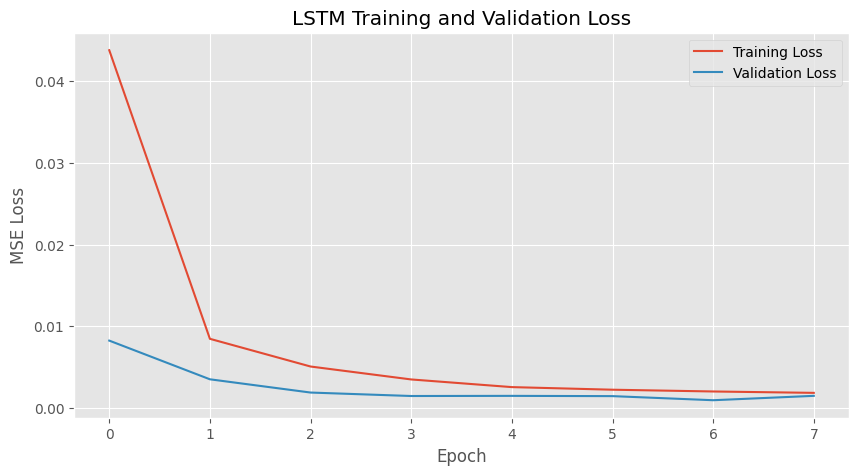

543/543 ━━━━━━━━━━━━━━━━━━━━ 10s 17ms/step
LSTM Performance


,Model,RMSE,MAE,MAPE
0,LSTM,1417.899021,1031.516313,1.887774


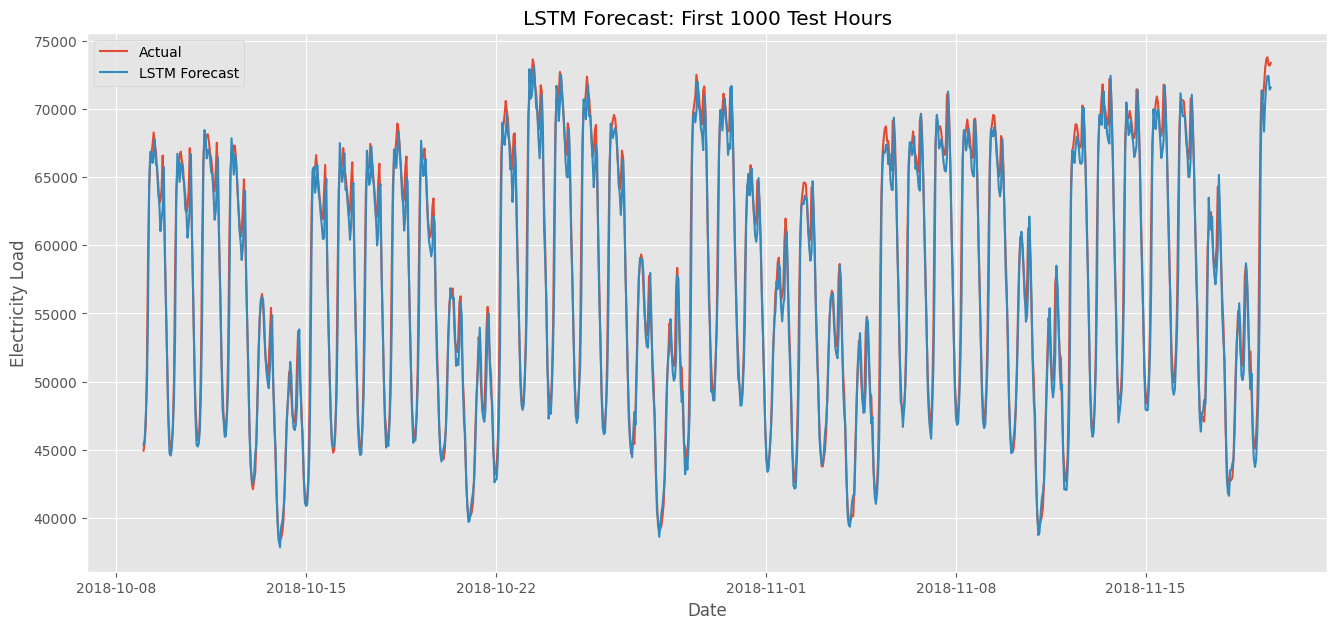

Final Model Comparison


,Model,RMSE,MAE,MAPE
7,LSTM,1417.899021,1031.516313,1.887774
0,SARIMA,2674.831119,2134.795248,4.029930
1,Random Forest,2688.138969,1981.349135,3.816028
2,Seasonal Naive,3006.760812,2318.520585,4.408920
3,SARIMAX,3055.214233,2266.895399,4.356206
4,Mean,4397.299694,3788.833122,6.969238
5,Naive,4459.108546,3783.202934,6.790082
6,Drift,5117.957264,4339.890674,8.049685


In [ ]:
# ==========================================================
# PART 6 - LSTM Forecasting and Evaluation
# ==========================================================

# Plot training history
plt.figure(figsize=(10,5))
plt.plot(history.history["loss"], label="Training Loss")
plt.plot(history.history["val_loss"], label="Validation Loss")
plt.title("LSTM Training and Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("MSE Loss")
plt.legend()
plt.grid(True)

plt.savefig("lstm_training_loss.png", dpi=300, bbox_inches="tight")

plt.show()

# Make predictions
lstm_predictions_scaled = model.predict(X_test_lstm)

# Convert predictions and actual values back to original scale
lstm_predictions = scaler.inverse_transform(lstm_predictions_scaled)
y_test_actual = scaler.inverse_transform(y_test_lstm.reshape(-1, 1))

# Create time index for predictions
lstm_test_index = test_hourly.index[window_size:]

# Evaluation metrics
lstm_rmse = rmse(y_test_actual, lstm_predictions)
lstm_mae = mae(y_test_actual, lstm_predictions)
lstm_mape = mape(y_test_actual, lstm_predictions)

lstm_result = pd.DataFrame({
    "Model": ["LSTM"],
    "RMSE": [lstm_rmse],
    "MAE": [lstm_mae],
    "MAPE": [lstm_mape]
})

print("LSTM Performance")
display(lstm_result)

# Plot actual vs predicted hourly demand
plt.figure(figsize=(16,7))
plt.plot(lstm_test_index[:1000], y_test_actual[:1000], label="Actual")
plt.plot(lstm_test_index[:1000], lstm_predictions[:1000], label="LSTM Forecast")
plt.title("LSTM Forecast: First 1000 Test Hours")
plt.xlabel("Date")
plt.ylabel("Electricity Load")
plt.legend()
plt.grid(True)
plt.savefig("lstm_forecast.png", dpi=300, bbox_inches="tight")
plt.show()

# Add LSTM to comparison table
final_comparison = pd.concat(
    [
        comparison,
        lstm_result
    ],
    ignore_index=True
).sort_values("RMSE")

print("Final Model Comparison")
display(final_comparison)

final_comparison.to_csv("model_comparison.csv", index=False)